# DDA Machine Learning
## Task 1: Linear Regression


In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.window import Window
from pyspark.sql import DataFrame as SparkDataFrame
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression
import pandas as pd
import sys


In [ ]:
spark = SparkSession.builder \
    .appName("DDA_ML") \
    .config("spark.pyspark.python", sys.executable) \
    .config("spark.pyspark.driver.python", sys.executable) \
    .config("spark.sql.shuffle.partitions", "12") \
    .config("spark.executor.memory", "4g") \
    .config("spark.executor.cores", "4") \
    .config("spark.sql.adaptive.enabled", "true") \
    .config("spark.sql.adaptive.coalescePartitions.enabled", "true") \
    .getOrCreate()

spark


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/01 22:27:08 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


### 1) Load cleaned dataset (`df_all.xlsx`) into Spark


In [3]:
df_all = spark.read.parquet("hdfs://localhost:9005/user/muhammed_mahmoud/silver/df_all.parquet")

In [4]:
print(f"Rows: {df_all.count()}, Columns: {len(df_all.columns)}")
df_all.printSchema()
df_all.show(5)

Rows: 1022552, Columns: 8
root
 |-- Invoice: string (nullable = true)
 |-- StockCode: integer (nullable = true)
 |-- Description: string (nullable = true)
 |-- Quantity: integer (nullable = true)
 |-- InvoiceDate: timestamp (nullable = true)
 |-- Price: float (nullable = true)
 |-- Customer ID: integer (nullable = true)
 |-- Country: string (nullable = true)



+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
|Invoice|StockCode|         Description|Quantity|        InvoiceDate|Price|Customer ID|       Country|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
| 503062|    21548|CERAMIC BIRDHOUSE...|       1|2010-03-29 16:48:00| 2.95|      14606|United Kingdom|
| 503068|    22582|PACK OF 6 SWEETIE...|       6|2010-03-30 10:26:00| 2.55|      15713|United Kingdom|
| 503150|    21272|  SALLE DE BAIN HOOK|       1|2010-03-30 12:22:00| 1.25|      15862|United Kingdom|
| 503162|    85205|PINK FELT EASTER ...|       6|2010-03-30 13:12:00| 2.55|      17586|United Kingdom|
| 503165|    21155|  RED SPOTTY PEG BAG|     150|2010-03-30 13:19:00| 1.69|      13694|United Kingdom|
+-------+---------+--------------------+--------+-------------------+-----+-----------+--------------+
only showing top 5 rows


### 2) Build forecasting target (daily revenue) and clean required fields


In [5]:
df_base = (
    df_all
    .withColumn("InvoiceDate", F.to_timestamp(F.col("InvoiceDate")))
    .withColumn("Quantity", F.col("Quantity").cast("double"))
    .withColumn("Price", F.col("Price").cast("double"))
    .withColumn("Revenue", F.col("Quantity") * F.col("Price"))
    .dropna(subset=["InvoiceDate", "Revenue"])
)

df_daily = (
    df_base
    .withColumn("event_date", F.to_date("InvoiceDate"))
    .groupBy("event_date")
    .agg(F.sum("Revenue").alias("target"))
    .orderBy("event_date")
)

print(f"Daily points: {df_daily.count()}")
df_daily.show(10, truncate=False)


Daily points: 604


+----------+------------------+
|event_date|target            |
+----------+------------------+
|2009-12-01|53777.55999082327 |
|2009-12-02|62391.269642837346|
|2009-12-03|76970.7297995016  |
|2009-12-04|39698.75988006964 |
|2009-12-05|9803.049890518188 |
|2009-12-06|24581.459803193808|
|2009-12-07|43360.27978207171 |
|2009-12-08|54422.54963102937 |
|2009-12-09|39070.21977492422 |
|2009-12-10|43208.69972130656 |
+----------+------------------+
only showing top 10 rows


In [6]:
spark.sparkContext.setLogLevel("ERROR")

### 3) Feature engineering (lag + rolling + seasonal)


In [7]:
w_order = Window.orderBy("event_date")
w_roll7 = Window.orderBy("event_date").rowsBetween(-7, -1)
w_roll28 = Window.orderBy("event_date").rowsBetween(-28, -1)

df_feat = (
    df_daily
    .withColumn("lag_1", F.lag("target", 1).over(w_order))
    .withColumn("lag_7", F.lag("target", 7).over(w_order))
    .withColumn("lag_14", F.lag("target", 14).over(w_order))
    .withColumn("lag_28", F.lag("target", 28).over(w_order))
    .withColumn("rolling_mean_7", F.avg("target").over(w_roll7))
    .withColumn("rolling_std_7", F.stddev("target").over(w_roll7))
    .withColumn("rolling_mean_28", F.avg("target").over(w_roll28))
    .withColumn("day_of_week", F.dayofweek("event_date"))
    .withColumn("week_of_year", F.weekofyear("event_date"))
    .withColumn("month", F.month("event_date"))
    .withColumn("quarter", F.quarter("event_date"))
    .withColumn("is_weekend", F.when(F.dayofweek("event_date").isin([1, 7]), 1).otherwise(0))
)

feature_cols = [
    "lag_1", "lag_7", "lag_14", "lag_28",
    "rolling_mean_7", "rolling_std_7", "rolling_mean_28",
    "day_of_week", "week_of_year", "month", "quarter", "is_weekend"
]

model_df = df_feat.dropna(subset=feature_cols + ["target"]).orderBy("event_date")
print(f"Modeling rows after feature engineering: {model_df.count()}")
model_df.select("event_date", "target", *feature_cols).show(10, truncate=False)


Modeling rows after feature engineering: 576
+----------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------+------------+-----+-------+----------+
|event_date|target            |lag_1             |lag_7             |lag_14            |lag_28            |rolling_mean_7    |rolling_std_7     |rolling_mean_28   |day_of_week|week_of_year|month|quarter|is_weekend|
+----------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+-----------+------------+-----+-------+----------+
|2010-01-12|40274.47988216579 |34498.8999504745  |13631.449963599443|50167.969781406224|53777.55999082327 |28839.565531082717|21655.00056367536 |36402.6787698394  |3          |2           |1    |1      |0         |
|2010-01-13|20278.44992493093 |40274.47988216579 |19224.78990748152 |30797.979910597205|62391.2

### 4) Chronological split (train/validation/test)


In [8]:
total_rows = model_df.count()
train_end = int(total_rows * 0.70)
valid_end = int(total_rows * 0.85)

w_idx = Window.orderBy("event_date")
indexed = model_df.withColumn("row_num", F.row_number().over(w_idx))

train_df = indexed.filter(F.col("row_num") <= train_end).drop("row_num")
valid_df = indexed.filter((F.col("row_num") > train_end) & (F.col("row_num") <= valid_end)).drop("row_num")
test_df = indexed.filter(F.col("row_num") > valid_end).drop("row_num")

print(f"Train rows: {train_df.count()}")
print(f"Validation rows: {valid_df.count()}")
print(f"Test rows: {test_df.count()}")


Train rows: 403
Validation rows: 86


Test rows: 87


### 5) Train first model: Linear Regression (PySpark ML)


In [9]:
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
lr = LinearRegression(featuresCol="features", labelCol="target", predictionCol="prediction")

pipeline = Pipeline(stages=[assembler, lr])
lr_model = pipeline.fit(train_df)

pred_valid = lr_model.transform(valid_df)
pred_test = lr_model.transform(test_df)

pred_test.select("event_date", "target", "prediction").show(10, truncate=False)


+----------+------------------+------------------+
|event_date|target            |prediction        |
+----------+------------------+------------------+
|2011-08-31|32529.909855639562|33759.94960938158 |
|2011-09-01|36811.879726946354|29569.066488222827|
|2011-09-02|40271.99972864054 |26616.103472809045|
|2011-09-04|16975.589895278215|16559.67061622603 |
|2011-09-05|36589.449915379286|34177.44812642594 |
|2011-09-06|28295.349781244993|37428.99667912083 |
|2011-09-07|32069.27987013012 |37404.72946224721 |
|2011-09-08|27064.23986021988 |33771.66916139364 |
|2011-09-09|30071.52984570712 |30132.432817942838|
|2011-09-11|34941.11977729201 |16659.064263096596|
+----------+------------------+------------------+
only showing top 10 rows


### 6) Evaluate model performance (MAE, RMSE, MAPE)


In [10]:
def regression_metrics(pred_df, label_col="target", pred_col="prediction"):
    err = F.col(pred_col) - F.col(label_col)
    ape = F.when(F.abs(F.col(label_col)) > F.lit(1e-8), F.abs(err / F.col(label_col)))

    row = (
        pred_df
        .select(
            F.avg(F.abs(err)).alias("MAE"),
            F.sqrt(F.avg(F.pow(err, 2))).alias("RMSE"),
            (F.avg(ape) * 100.0).alias("MAPE_percent")
        )
        .first()
    )
    return {"MAE": row["MAE"], "RMSE": row["RMSE"], "MAPE_percent": row["MAPE_percent"]}

valid_metrics = regression_metrics(pred_valid)
test_metrics = regression_metrics(pred_test)

print("Validation Metrics:", valid_metrics)
print("Test Metrics:", test_metrics)


Validation Metrics: {'MAE': 9901.60027789232, 'RMSE': 12428.232626602487, 'MAPE_percent': 41.473675223491604}
Test Metrics: {'MAE': 15017.374776956198, 'RMSE': 36623.968861241316, 'MAPE_percent': 28.561931437435085}


### 7) Save test predictions


In [11]:
# (
#     pred_test
#     .select("event_date", "target", "prediction")
#     .orderBy("event_date")
#     .toPandas()
#     .to_csv("/content/drive/MyDrive/DDA/task1_linear_regression_test_predictions.csv", index=False)
# )

pred_test.select("event_date", "target", "prediction").orderBy("event_date").write.parquet("hdfs://localhost:9005/user/muhammed_mahmoud/gold/lr_pred_test.parquet", mode="overwrite")

print("Saved: lr_pred_test.parquet")

Saved: lr_pred_test.parquet


## Task 2: Random Forest Forecasting


### 8) Train Random Forest with validation-based selection


In [12]:
from pyspark.ml.regression import RandomForestRegressor

rf_candidates = [
    {"numTrees": 100, "maxDepth": 8, "minInstancesPerNode": 1},
    {"numTrees": 200, "maxDepth": 10, "minInstancesPerNode": 1},
    {"numTrees": 300, "maxDepth": 12, "minInstancesPerNode": 2}
]

best_rf_model = None
best_rf_cfg = None
best_rf_rmse = float("inf")

for cfg in rf_candidates:
    rf = RandomForestRegressor(
        featuresCol="features",
        labelCol="target",
        predictionCol="prediction",
        numTrees=cfg["numTrees"],
        maxDepth=cfg["maxDepth"],
        minInstancesPerNode=cfg["minInstancesPerNode"],
        seed=42
    )

    rf_pipeline = Pipeline(stages=[assembler, rf])
    rf_model = rf_pipeline.fit(train_df)

    rf_valid_pred = rf_model.transform(valid_df)
    rf_valid_metrics = regression_metrics(rf_valid_pred)

    print(f"Config: {cfg} -> Validation RMSE: {rf_valid_metrics['RMSE']:.4f}, MAE: {rf_valid_metrics['MAE']:.4f}, MAPE: {rf_valid_metrics['MAPE_percent']:.4f}")

    if rf_valid_metrics["RMSE"] < best_rf_rmse:
        best_rf_rmse = rf_valid_metrics["RMSE"]
        best_rf_model = rf_model
        best_rf_cfg = cfg

print("Best Random Forest config:", best_rf_cfg)

Config: {'numTrees': 100, 'maxDepth': 8, 'minInstancesPerNode': 1} -> Validation RMSE: 12020.0343, MAE: 9377.6571, MAPE: 42.3186


Config: {'numTrees': 200, 'maxDepth': 10, 'minInstancesPerNode': 1} -> Validation RMSE: 11896.7360, MAE: 9376.8992, MAPE: 42.1000


Config: {'numTrees': 300, 'maxDepth': 12, 'minInstancesPerNode': 2} -> Validation RMSE: 11806.7881, MAE: 9305.8332, MAPE: 41.9922
Best Random Forest config: {'numTrees': 300, 'maxDepth': 12, 'minInstancesPerNode': 2}


### 9) Evaluate Random Forest on validation and test

In [13]:
rf_pred_valid = best_rf_model.transform(valid_df)
rf_pred_test = best_rf_model.transform(test_df)

rf_valid_metrics = regression_metrics(rf_pred_valid)
rf_test_metrics = regression_metrics(rf_pred_test)

print("Random Forest Validation Metrics:", rf_valid_metrics)
print("Random Forest Test Metrics:", rf_test_metrics)

rf_pred_test.select("event_date", "target", "prediction").show(10, truncate=False)


Random Forest Validation Metrics: {'MAE': 9305.833212867155, 'RMSE': 11806.788051090245, 'MAPE_percent': 41.99223200063299}
Random Forest Test Metrics: {'MAE': 14683.366718401046, 'RMSE': 36694.64341480557, 'MAPE_percent': 27.44527502365836}


+----------+------------------+------------------+
|event_date|target            |prediction        |
+----------+------------------+------------------+
|2011-08-31|32529.909855639562|37351.94672412491 |
|2011-09-01|36811.879726946354|32087.711061373222|
|2011-09-02|40271.99972864054 |31613.36260300547 |
|2011-09-04|16975.589895278215|19929.755331659595|
|2011-09-05|36589.449915379286|30305.836682159374|
|2011-09-06|28295.349781244993|37234.99495256453 |
|2011-09-07|32069.27987013012 |33883.77084744577 |
|2011-09-08|27064.23986021988 |35860.757202300156|
|2011-09-09|30071.52984570712 |30613.839708518175|
|2011-09-11|34941.11977729201 |18330.960918143486|
+----------+------------------+------------------+
only showing top 10 rows


### 10) Save Random Forest test predictions


In [14]:
# (
#     rf_pred_test
#     .select("event_date", "target", "prediction")
#     .orderBy("event_date")
#     .toPandas()
#     .to_csv("/content/drive/MyDrive/DDA/task2_random_forest_test_predictions.csv", index=False)
# )

rf_pred_test.select("event_date", "target", "prediction").orderBy("event_date").write.parquet("hdfs://localhost:9005/user/muhammed_mahmoud/gold/rf_pred_test.parquet", mode="overwrite")

print("Saved: rf_pred_test.parquet")

Saved: rf_pred_test.parquet


## Task 3: Gradient Boosting Forecasting


### 11) Train Gradient Boosting with validation-based selection


In [15]:
from pyspark.ml.regression import GBTRegressor

gbt_candidates = [
    {"maxIter": 100, "stepSize": 0.1, "maxDepth": 5},
    {"maxIter": 200, "stepSize": 0.05, "maxDepth": 6},
    # {"maxIter": 300, "stepSize": 0.03, "maxDepth": 7}
]

best_gbt_model = None
best_gbt_cfg = None
best_gbt_rmse = float("inf")

for cfg in gbt_candidates:
    gbt = GBTRegressor(
        featuresCol="features",
        labelCol="target",
        predictionCol="prediction",
        maxIter=cfg["maxIter"],
        stepSize=cfg["stepSize"],
        maxDepth=cfg["maxDepth"],
        seed=42
    )

    gbt_pipeline = Pipeline(stages=[assembler, gbt])
    gbt_model = gbt_pipeline.fit(train_df)

    gbt_valid_pred = gbt_model.transform(valid_df)
    gbt_valid_metrics = regression_metrics(gbt_valid_pred)

    print(f"Config: {cfg} -> Validation RMSE: {gbt_valid_metrics['RMSE']:.4f}, MAE: {gbt_valid_metrics['MAE']:.4f}, MAPE: {gbt_valid_metrics['MAPE_percent']:.4f}")

    if gbt_valid_metrics["RMSE"] < best_gbt_rmse:
        best_gbt_rmse = gbt_valid_metrics["RMSE"]
        best_gbt_model = gbt_model
        best_gbt_cfg = cfg

print("Best Gradient Boosting config:", best_gbt_cfg)


Config: {'maxIter': 100, 'stepSize': 0.1, 'maxDepth': 5} -> Validation RMSE: 13455.4755, MAE: 9506.3777, MAPE: 38.0067
Config: {'maxIter': 200, 'stepSize': 0.05, 'maxDepth': 6} -> Validation RMSE: 13216.0845, MAE: 9593.7596, MAPE: 39.5742
Best Gradient Boosting config: {'maxIter': 200, 'stepSize': 0.05, 'maxDepth': 6}


### 12) Evaluate Gradient Boosting on validation and test


In [16]:
gbt_pred_valid = best_gbt_model.transform(valid_df)
gbt_pred_test = best_gbt_model.transform(test_df)

gbt_valid_metrics = regression_metrics(gbt_pred_valid)
gbt_test_metrics = regression_metrics(gbt_pred_test)

print("Gradient Boosting Validation Metrics:", gbt_valid_metrics)
print("Gradient Boosting Test Metrics:", gbt_test_metrics)

gbt_pred_test.select("event_date", "target", "prediction").show(10, truncate=False)

Gradient Boosting Validation Metrics: {'MAE': 9593.759574937378, 'RMSE': 13216.084496975542, 'MAPE_percent': 39.57419385945936}
Gradient Boosting Test Metrics: {'MAE': 17684.889537924613, 'RMSE': 38835.32727512121, 'MAPE_percent': 31.833192160820467}
+----------+------------------+------------------+
|event_date|target            |prediction        |
+----------+------------------+------------------+
|2011-08-31|32529.909855639562|50560.818020761464|
|2011-09-01|36811.879726946354|36357.550072097656|
|2011-09-02|40271.99972864054 |39618.337915251315|
|2011-09-04|16975.589895278215|25432.602118601368|
|2011-09-05|36589.449915379286|29893.159819791814|
|2011-09-06|28295.349781244993|33980.7541549915  |
|2011-09-07|32069.27987013012 |35850.23679193234 |
|2011-09-08|27064.23986021988 |36002.9745537028  |
|2011-09-09|30071.52984570712 |27455.076240302184|
|2011-09-11|34941.11977729201 |23496.411016598166|
+----------+------------------+------------------+
only showing top 10 rows


### 13) Save Gradient Boosting test predictions


In [17]:
# (
#     gbt_pred_test
#     .select("event_date", "target", "prediction")
#     .orderBy("event_date")
#     .toPandas()
#     .to_csv("/content/drive/MyDrive/DDA/task3_gradient_boosting_test_predictions.csv", index=False)
# )

gbt_pred_test.select("event_date", "target", "prediction").orderBy("event_date").write.parquet("hdfs://localhost:9005/user/muhammed_mahmoud/gold/gbt_pred_test.parquet", mode="overwrite")

print("Saved: gbt_pred_test.parquet")

Saved: gbt_pred_test.parquet


## Task 4: Prophet Forecasting

### 14) Prepare univariate daily series for Prophet

In [18]:
import numpy as np
from prophet import Prophet

ts_pdf = (
    model_df
    .select("event_date", "target")
    .orderBy("event_date")
    .toPandas()
)

ts_pdf["event_date"] = pd.to_datetime(ts_pdf["event_date"])
ts_pdf = ts_pdf.sort_values("event_date").reset_index(drop=True)
ts_pdf["target"] = ts_pdf["target"].astype(float)

print("Prophet dataset size:", len(ts_pdf))
ts_pdf.head()

/home/muhammed_mahmoud/Projects/python_env/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Prophet dataset size: 576


,event_date,target
0,2010-01-12,40274.479882
1,2010-01-13,20278.449925
2,2010-01-14,31029.909862
3,2010-01-15,13557.609888
4,2010-01-17,17395.499897


### 15) Chronological split and Prophet hyperparameter selection on validation

In [19]:
# Reuse the exact chronological train/valid/test split from Task 1
train_prophet = (
    train_df
    .select("event_date", "target")
    .orderBy("event_date")
    .toPandas()
    .rename(columns={"event_date": "ds", "target": "y"})
)
valid_prophet = (
    valid_df
    .select("event_date", "target")
    .orderBy("event_date")
    .toPandas()
    .rename(columns={"event_date": "ds", "target": "y"})
)
test_prophet = (
    test_df
    .select("event_date", "target")
    .orderBy("event_date")
    .toPandas()
    .rename(columns={"event_date": "ds", "target": "y"})
)

print("Train points:", len(train_prophet))
print("Validation points:", len(valid_prophet))
print("Test points:", len(test_prophet))


def ts_metrics(actual, pred):
    actual = np.array(actual, dtype=float)
    pred = np.array(pred, dtype=float)
    err = pred - actual
    mae = np.mean(np.abs(err))
    rmse = np.sqrt(np.mean(err ** 2))
    mask = np.abs(actual) > 1e-8
    mape = np.mean(np.abs(err[mask] / actual[mask])) * 100 if np.any(mask) else np.nan
    return {"MAE": float(mae), "RMSE": float(rmse), "MAPE_percent": float(mape)}

candidate_params = [
    {"changepoint_prior_scale": 0.01, "seasonality_mode": "additive"},
    {"changepoint_prior_scale": 0.05, "seasonality_mode": "additive"},
    {"changepoint_prior_scale": 0.10, "seasonality_mode": "additive"},
    {"changepoint_prior_scale": 0.20, "seasonality_mode": "multiplicative"}
]

best_prophet_params = None
best_valid_rmse = float("inf")

for params in candidate_params:
    try:
        model = Prophet(
            changepoint_prior_scale=params["changepoint_prior_scale"],
            seasonality_mode=params["seasonality_mode"],
            yearly_seasonality=True,
            weekly_seasonality=True,
            daily_seasonality=False
        )
        model.fit(train_prophet)
        valid_forecast = model.predict(valid_prophet[["ds"]])
        valid_m = ts_metrics(valid_prophet["y"].values, valid_forecast["yhat"].values)
        print(
            f"Params {params} -> Validation RMSE: {valid_m['RMSE']:.4f}, "
            f"MAE: {valid_m['MAE']:.4f}, MAPE: {valid_m['MAPE_percent']:.4f}"
        )

        if valid_m["RMSE"] < best_valid_rmse:
            best_valid_rmse = valid_m["RMSE"]
            best_prophet_params = params
    except Exception as e:
        print(f"Params {params} failed: {e}")

print("Best Prophet params:", best_prophet_params)

22:32:59 - cmdstanpy - INFO - Chain [1] start processing


Train points: 403
Validation points: 86
Test points: 87


22:32:59 - cmdstanpy - INFO - Chain [1] done processing
22:32:59 - cmdstanpy - INFO - Chain [1] start processing
22:32:59 - cmdstanpy - INFO - Chain [1] done processing


Params {'changepoint_prior_scale': 0.01, 'seasonality_mode': 'additive'} -> Validation RMSE: 11860.6467, MAE: 8407.2476, MAPE: 32.5368


22:33:00 - cmdstanpy - INFO - Chain [1] start processing
22:33:00 - cmdstanpy - INFO - Chain [1] done processing


Params {'changepoint_prior_scale': 0.05, 'seasonality_mode': 'additive'} -> Validation RMSE: 11801.3368, MAE: 8459.0820, MAPE: 33.4925


22:33:00 - cmdstanpy - INFO - Chain [1] start processing
22:33:00 - cmdstanpy - INFO - Chain [1] done processing


Params {'changepoint_prior_scale': 0.1, 'seasonality_mode': 'additive'} -> Validation RMSE: 11776.9266, MAE: 8492.2363, MAPE: 34.0254
Params {'changepoint_prior_scale': 0.2, 'seasonality_mode': 'multiplicative'} -> Validation RMSE: 12955.4548, MAE: 8592.4284, MAPE: 28.7409
Best Prophet params: {'changepoint_prior_scale': 0.1, 'seasonality_mode': 'additive'}


### 16) Refit with best order and evaluate on test

In [20]:
train_valid_prophet = pd.concat([train_prophet, valid_prophet], ignore_index=True).sort_values("ds").reset_index(drop=True)

final_prophet = Prophet(
    changepoint_prior_scale=best_prophet_params["changepoint_prior_scale"],
    seasonality_mode=best_prophet_params["seasonality_mode"],
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)
final_prophet.fit(train_valid_prophet)
test_forecast = final_prophet.predict(test_prophet[["ds"]])

prophet_test_metrics = ts_metrics(test_prophet["y"].values, test_forecast["yhat"].values)
print("Prophet Test Metrics:", prophet_test_metrics)

prophet_test_pred = pd.DataFrame({
    "event_date": test_prophet["ds"].values,
    "target": test_prophet["y"].values,
    "prediction": test_forecast["yhat"].values
})

prophet_test_pred.head(10)

22:33:00 - cmdstanpy - INFO - Chain [1] start processing
22:33:00 - cmdstanpy - INFO - Chain [1] done processing


Prophet Test Metrics: {'MAE': 15039.32257543356, 'RMSE': 37984.5664771508, 'MAPE_percent': 29.4241819666265}


,event_date,target,prediction
0,2011-08-31,32529.909856,24353.922288
1,2011-09-01,36811.879727,30002.835455
2,2011-09-02,40271.999729,21025.813879
3,2011-09-04,16975.589895,9359.793688
4,2011-09-05,36589.449915,26010.933527
5,2011-09-06,28295.349781,28927.026239
6,2011-09-07,32069.279870,22605.778509
7,2011-09-08,27064.239860,29137.094594
8,2011-09-09,30071.529846,21141.443215
9,2011-09-11,34941.119777,11658.191809


### 17) Save Prophet test predictions

In [21]:
# prophet_test_pred.to_csv("/content/drive/MyDrive/DDA/task4_prophet_test_predictions.csv", index=False)
prophet_test_pred = spark.createDataFrame(prophet_test_pred).orderBy("event_date")
prophet_test_pred.write.parquet("hdfs://localhost:9005/user/muhammed_mahmoud/gold/prophet_pred_test.parquet", mode="overwrite")
print("Saved: prophet_pred_test.parquet")

Saved: prophet_pred_test.parquet


## Final Comparison: Four Models (Test Metrics)

This cell compares Linear Regression, Random Forest, Gradient Boosting, and Prophet on the test split, prints a formatted table, and saves it as CSV.


In [22]:
comparison_df = pd.DataFrame([
    {
        "Model": "Linear Regression",
        "MAE": test_metrics["MAE"],
        "RMSE": test_metrics["RMSE"],
        "MAPE_percent": test_metrics["MAPE_percent"]
    },
    {
        "Model": "Random Forest",
        "MAE": rf_test_metrics["MAE"],
        "RMSE": rf_test_metrics["RMSE"],
        "MAPE_percent": rf_test_metrics["MAPE_percent"]
    },
    {
        "Model": "Gradient Boosting",
        "MAE": gbt_test_metrics["MAE"],
        "RMSE": gbt_test_metrics["RMSE"],
        "MAPE_percent": gbt_test_metrics["MAPE_percent"]
    },
    {
        "Model": "Prophet",
        "MAE": prophet_test_metrics["MAE"],
        "RMSE": prophet_test_metrics["RMSE"],
        "MAPE_percent": prophet_test_metrics["MAPE_percent"]
    }
])

comparison_df = comparison_df.sort_values("RMSE", ascending=True).reset_index(drop=True)
comparison_df[["MAE", "RMSE", "MAPE_percent"]] = comparison_df[["MAE", "RMSE", "MAPE_percent"]].round(4)

print("Model Performance Comparison (Test Set)")
print(comparison_df.to_string(index=False))

display(comparison_df)
# comparison_df.to_csv("/content/drive/MyDrive/DDA/model_comparison_metrics.csv", index=False)
comparison_df = spark.createDataFrame(comparison_df).orderBy("RMSE")
comparison_df.write.parquet("hdfs://localhost:9005/user/muhammed_mahmoud/gold/models_comparison_metrics.parquet", mode="overwrite")
print("Saved: models_comparison_metrics.parquet")


Model Performance Comparison (Test Set)
            Model        MAE       RMSE  MAPE_percent
Linear Regression 15017.3748 36623.9689       28.5619
    Random Forest 14683.3667 36694.6434       27.4453
          Prophet 15039.3226 37984.5665       29.4242
Gradient Boosting 17684.8895 38835.3273       31.8332


,Model,MAE,RMSE,MAPE_percent
0,Linear Regression,15017.3748,36623.9689,28.5619
1,Random Forest,14683.3667,36694.6434,27.4453
2,Prophet,15039.3226,37984.5665,29.4242
3,Gradient Boosting,17684.8895,38835.3273,31.8332


Saved: models_comparison_metrics.parquet


## Visual Comparison: Four Models

These visuals compare test-set MAE, RMSE, and MAPE across the four forecasting models.

In [23]:
def save_plot_to_hdfs(spark, local_path, hdfs_path):
    jvm = spark._jvm
    
    hadoop_conf = spark._jsc.hadoopConfiguration()
    
    # Explicitly get HDFS filesystem
    uri = jvm.java.net.URI.create(hdfs_path)
    fs = jvm.org.apache.hadoop.fs.FileSystem.get(uri, hadoop_conf)

    fs.copyFromLocalFile(
        False,
        True,
        jvm.org.apache.hadoop.fs.Path(local_path),
        jvm.org.apache.hadoop.fs.Path(hdfs_path)
    )
def ensure_pandas(df):
    if isinstance(df, SparkDataFrame):
        return df.toPandas()
    elif isinstance(df, pd.DataFrame):
        return df
    else:
        raise TypeError(f"Unsupported type: {type(df)}")

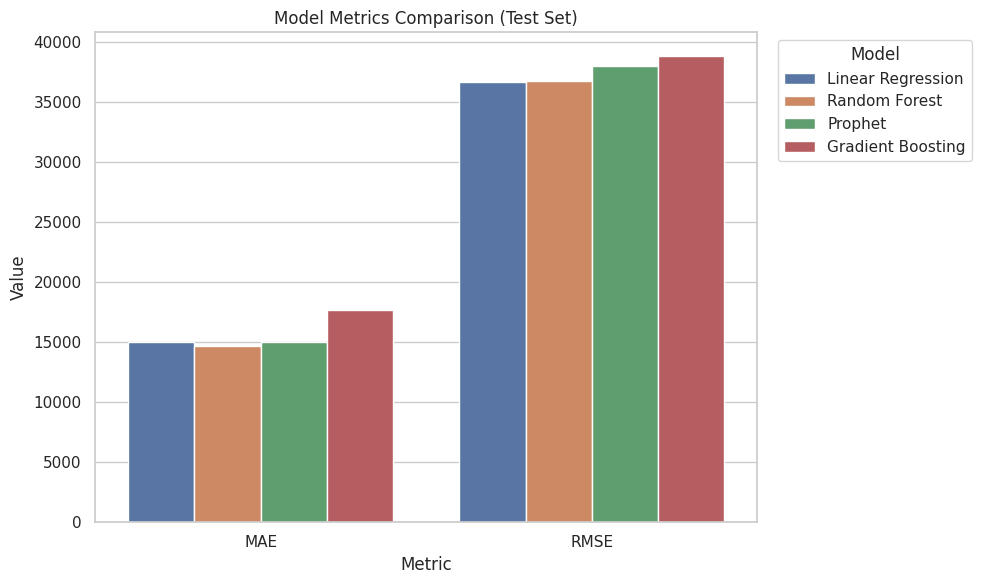

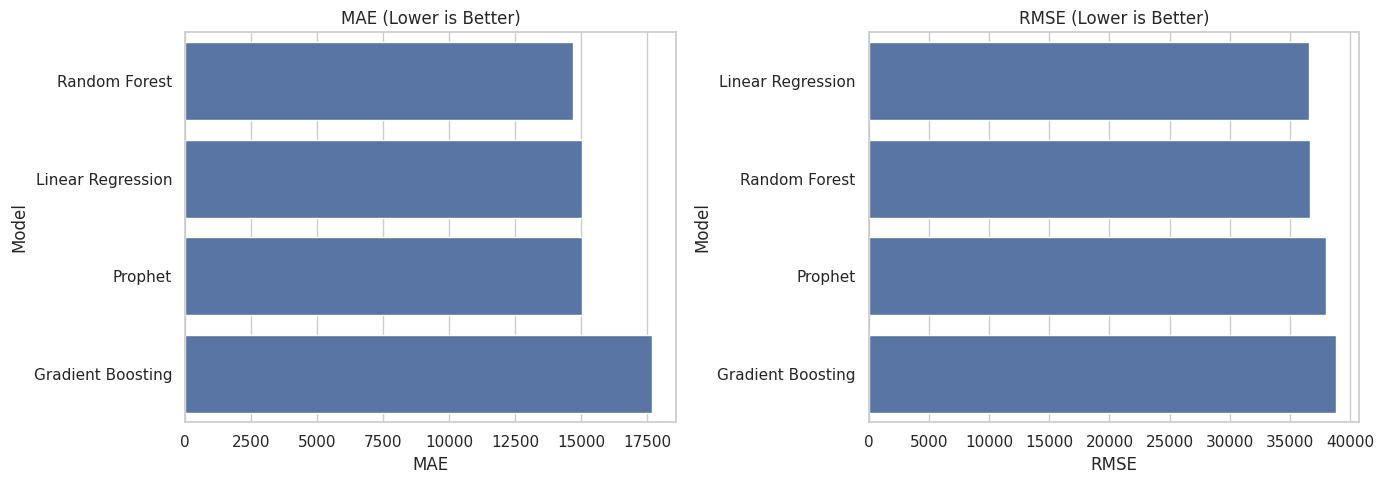

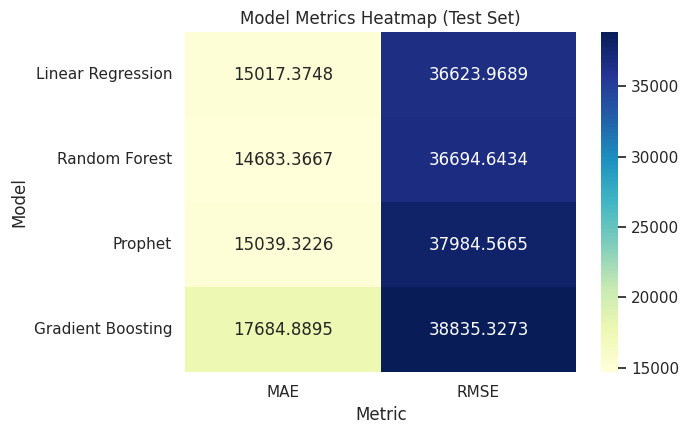

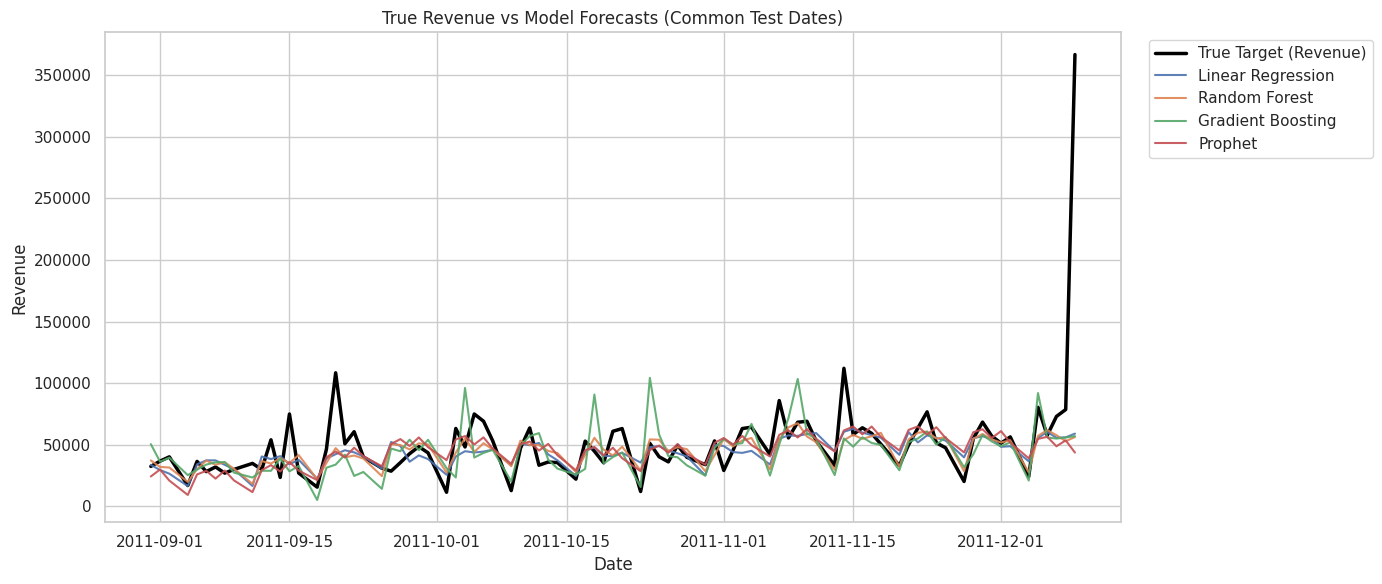

Saved visual files:
- model_metrics_grouped_bar.png
- model_metrics_per_metric.png
- model_metrics_heatmap.png
- model_forecast_timeseries_comparison.png


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns


comparison_df = ensure_pandas(comparison_df)
prophet_test_pred = ensure_pandas(prophet_test_pred)
# Ensure style is clean and consistent
sns.set_theme(style="whitegrid", context="notebook")

# 1) Grouped bar chart for MAE and RMSE only
metrics_to_plot = ["MAE", "RMSE"]
plot_df = comparison_df[["Model"] + metrics_to_plot].melt(id_vars="Model", var_name="Metric", value_name="Value")

plt.figure(figsize=(10, 6))
sns.barplot(data=plot_df, x="Metric", y="Value", hue="Model")
plt.title("Model Metrics Comparison (Test Set)")
plt.xlabel("Metric")
plt.ylabel("Value")
plt.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
# plt.savefig("/content/drive/MyDrive/DDA/model_metrics_grouped_bar.png", dpi=150)
plt.savefig("../output/model_metrics_grouped_bar.png", dpi=150)
plt.show()

# 2) Per-metric ranking bars (lower is better)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, metric in zip(axes, metrics_to_plot):
    mdf = comparison_df.sort_values(metric, ascending=True)
    sns.barplot(data=mdf, x=metric, y="Model", ax=ax)
    ax.set_title(f"{metric} (Lower is Better)")
    ax.set_xlabel(metric)
    ax.set_ylabel("Model")

plt.tight_layout()
plt.savefig("../output/model_metrics_per_metric.png", dpi=150)
plt.show()

# 3) Heatmap for compact MAE/RMSE comparison
heatmap_df = comparison_df.set_index("Model")[["MAE", "RMSE"]]

plt.figure(figsize=(7, 4.5))
sns.heatmap(heatmap_df, annot=True, fmt=".4f", cmap="YlGnBu", cbar=True)
plt.title("Model Metrics Heatmap (Test Set)")
plt.xlabel("Metric")
plt.ylabel("Model")
plt.tight_layout()
plt.savefig("../output/model_metrics_heatmap.png", dpi=150)
plt.show()

# 4) Time series comparison: true target vs four model predictions
lr_ts = (
    pred_test
    .select("event_date", "target", "prediction")
    .orderBy("event_date")
    .toPandas()
    .rename(columns={"prediction": "Linear Regression"})
)

rf_ts = (
    rf_pred_test
    .select("event_date", "prediction")
    .orderBy("event_date")
    .toPandas()
    .rename(columns={"prediction": "Random Forest"})
)

gbt_ts = (
    gbt_pred_test
    .select("event_date", "prediction")
    .orderBy("event_date")
    .toPandas()
    .rename(columns={"prediction": "Gradient Boosting"})
)

prophet_ts = prophet_test_pred[["event_date", "prediction"]].copy().rename(columns={"prediction": "Prophet"})

# Align by date so all model lines and true values are compared on common dates
for df_ in [lr_ts, rf_ts, gbt_ts, prophet_ts]:
    df_["event_date"] = pd.to_datetime(df_["event_date"])

ts_compare = (
    lr_ts[["event_date", "target", "Linear Regression"]]
    .merge(rf_ts, on="event_date", how="inner")
    .merge(gbt_ts, on="event_date", how="inner")
    .merge(prophet_ts, on="event_date", how="inner")
    .sort_values("event_date")
)

plt.figure(figsize=(14, 6))
plt.plot(ts_compare["event_date"], ts_compare["target"], label="True Target (Revenue)", linewidth=2.5, color="black")
plt.plot(ts_compare["event_date"], ts_compare["Linear Regression"], label="Linear Regression", alpha=0.9)
plt.plot(ts_compare["event_date"], ts_compare["Random Forest"], label="Random Forest", alpha=0.9)
plt.plot(ts_compare["event_date"], ts_compare["Gradient Boosting"], label="Gradient Boosting", alpha=0.9)
plt.plot(ts_compare["event_date"], ts_compare["Prophet"], label="Prophet", alpha=0.9)

plt.title("True Revenue vs Model Forecasts (Common Test Dates)")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.savefig("../output/model_forecast_timeseries_comparison.png", dpi=150)
plt.show()

save_plot_to_hdfs(spark, "../output/model_metrics_grouped_bar.png", "hdfs://localhost:9005/user/muhammed_mahmoud/gold/visualizations/model_metrics_grouped_bar.png")
save_plot_to_hdfs(spark, "../output/model_metrics_per_metric.png", "hdfs://localhost:9005/user/muhammed_mahmoud/gold/visualizations/model_metrics_per_metric.png")
save_plot_to_hdfs(spark, "../output/model_metrics_heatmap.png", "hdfs://localhost:9005/user/muhammed_mahmoud/gold/visualizations/model_metrics_heatmap.png")
save_plot_to_hdfs(spark, "../output/model_forecast_timeseries_comparison.png", "hdfs://localhost:9005/user/muhammed_mahmoud/gold/visualizations/model_forecast_timeseries_comparison.png")

print("Saved visual files:")
print("- model_metrics_grouped_bar.png")
print("- model_metrics_per_metric.png")
print("- model_metrics_heatmap.png")
print("- model_forecast_timeseries_comparison.png")


# MLOps Engineering: Deployment and Monitoring

In [25]:
import mlflow
import mlflow.spark

In [26]:
best_model = {
    "LinearRegression": {"params": {}, "model": lr_model, "metrics": test_metrics},
    "RandomForestRegressor": {
        "params": best_rf_cfg,
        "model": best_rf_model,
        "metrics": rf_test_metrics,
    },
    "GBTRegressor": {
        "params": best_gbt_cfg,
        "model": best_gbt_model,
        "metrics": gbt_test_metrics,
    },
    "Prophet": {
        "params": best_prophet_params,
        "model": final_prophet,
        "metrics": prophet_test_metrics,
    },
}

In [27]:
import json, tempfile, os
import mlflow.prophet
from prophet.serialize import model_to_json

mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment("time_series_forecasting")

HDFS_MODEL_BASE = "hdfs://localhost:9005/user/muhammed_mahmoud/models"


for model_name, info in best_model.items():
    with mlflow.start_run(run_name=model_name) as run:
        if info["params"]:
            mlflow.log_params(info["params"])

        metrics = info["metrics"]
        mlflow.log_metrics({
            "MAE": metrics["MAE"],
            "RMSE": metrics["RMSE"],
            "MAPE": metrics["MAPE_percent"],
        })

        model = info["model"]
        run_id = run.info.run_id

        if model_name == "Prophet":
            # Save Prophet model as JSON (Prophet's native format)
            with tempfile.TemporaryDirectory() as tmp:
                model_path = os.path.join(tmp, "prophet_model.json")
                with open(model_path, "w") as f:
                    json.dump(model_to_json(model), f)
                mlflow.log_artifact(model_path, artifact_path="model")

            # Also save to HDFS for consistency with other models
            hdfs_path = f"{HDFS_MODEL_BASE}/{run_id}/Prophet"
            with tempfile.TemporaryDirectory() as tmp:
                model_path = os.path.join(tmp, "prophet_model.json")
                with open(model_path, "w") as f:
                    json.dump(model_to_json(model), f)

                # Copy local file to HDFS using Spark
                spark.sparkContext.addFile(model_path)
                local_df = spark.read.text(model_path)
                local_df.coalesce(1).write.mode("overwrite").text(hdfs_path)

            mlflow.set_tag("hdfs_model_path", hdfs_path)
            print(f"✔ Logged {model_name} | RMSE={metrics['RMSE']:.2f}")

        else:
            hdfs_path = f"{HDFS_MODEL_BASE}/{run_id}/{model_name}"
            model.write().overwrite().save(hdfs_path)
            mlflow.set_tag("hdfs_model_path", hdfs_path)

            with tempfile.TemporaryDirectory() as tmp:
                meta_path = os.path.join(tmp, "model_meta.json")
                with open(meta_path, "w") as f:
                    json.dump({"hdfs_path": hdfs_path, "model_type": model_name}, f)
                mlflow.log_artifact(meta_path)

            print(f"✔ Logged {model_name} | RMSE={metrics['RMSE']:.2f}")

2026/05/01 22:33:18 INFO mlflow.tracking.fluent: Experiment with name 'time_series_forecasting' does not exist. Creating a new experiment.


✔ Logged LinearRegression | RMSE=36623.97
🏃 View run LinearRegression at: http://localhost:5000/#/experiments/1/runs/4128aa97932846509395a15c4c3a9b6b
🧪 View experiment at: http://localhost:5000/#/experiments/1


✔ Logged RandomForestRegressor | RMSE=36694.64
🏃 View run RandomForestRegressor at: http://localhost:5000/#/experiments/1/runs/3789cb1814584700906aa1cebe7240e1
🧪 View experiment at: http://localhost:5000/#/experiments/1
✔ Logged GBTRegressor | RMSE=38835.33
🏃 View run GBTRegressor at: http://localhost:5000/#/experiments/1/runs/2225ccfae7294cd4864ba6ad2f2795a7
🧪 View experiment at: http://localhost:5000/#/experiments/1
✔ Logged Prophet | RMSE=37984.57
🏃 View run Prophet at: http://localhost:5000/#/experiments/1/runs/85196007c8b546eba5cd18877e772c49
🧪 View experiment at: http://localhost:5000/#/experiments/1


In [28]:
from mlflow.tracking import MlflowClient
from pyspark.ml import PipelineModel

In [29]:
mlflow.set_tracking_uri("http://localhost:5000")
client = MlflowClient()

# ── 1. Find the best RandomForest run ──────────────────────────────────────
experiment = client.get_experiment_by_name("time_series_forecasting")

runs = client.search_runs(
    experiment_ids=[experiment.experiment_id],
    filter_string="tags.mlflow.runName = 'RandomForestRegressor'",
    order_by=["metrics.RMSE ASC"],   # lower RMSE = better
    max_results=1
)

best_run = runs[0]
print("Best RF run:", best_run.info.run_id)
print("Metrics:", best_run.data.metrics)

Best RF run: 3789cb1814584700906aa1cebe7240e1
Metrics: {'MAE': 14683.366718401046, 'RMSE': 36694.64341480557, 'MAPE': 27.44527502365836}


In [30]:
# Load & evaluate
hdfs_path = best_run.data.tags.get("hdfs_model_path")
loaded_rf = PipelineModel.load(hdfs_path)
predictions_df = loaded_rf.transform(test_df)    # must be a Spark DataFrame
predictions_df.select("target", "prediction").show(10)

+------------------+------------------+
|            target|        prediction|
+------------------+------------------+
|32529.909855639562| 37351.94672412491|
|36811.879726946354|32087.711061373222|
| 40271.99972864054| 31613.36260300547|
|16975.589895278215|19929.755331659595|
|36589.449915379286|30305.836682159374|
|28295.349781244993| 37234.99495256453|
| 32069.27987013012| 33883.77084744577|
| 27064.23986021988|35860.757202300156|
| 30071.52984570712|30613.839708518175|
| 34941.11977729201|18330.960918143486|
+------------------+------------------+
only showing top 10 rows


In [31]:
# Compute RMSE on the loaded model
from pyspark.ml.evaluation import RegressionEvaluator

evaluator = RegressionEvaluator(
    labelCol="target",
    predictionCol="prediction",
    metricName="rmse"
)
rmse = evaluator.evaluate(predictions_df)
print(f"Loaded RF RMSE: {rmse:.2f}")

Loaded RF RMSE: 36694.64


In [32]:
# Register the model
result = mlflow.register_model(
    model_uri=hdfs_path,          # or f"runs:/{run_id}/model"
    name="RandomForest_TimeSeries_Prod"
)
print("Registered model:", result.name)
print("Version:", result.version)

Successfully registered model 'RandomForest_TimeSeries_Prod'.
2026/05/01 22:33:42 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: RandomForest_TimeSeries_Prod, version 1


Registered model: RandomForest_TimeSeries_Prod
Version: 1


Created version '1' of model 'RandomForest_TimeSeries_Prod'.


In [33]:
# Transition to Production
client.transition_model_version_stage(
    name="RandomForest_TimeSeries_Prod",
    version=result.version,
    stage="Production",
    archive_existing_versions=True   # demotes any previous Production version
)
print(f"Version {result.version} is now in Production")

/tmp/ipykernel_414335/2511137664.py:2: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(


Version 1 is now in Production


In [34]:
PROD_PATH = "hdfs://localhost:9005/user/muhammed_mahmoud/models/production/RandomForest"

# ── Save to production ─────────────────────────────────────────────────────
best_rf_model.write().overwrite().save(PROD_PATH)
print(f"✔ Saved to {PROD_PATH}")

✔ Saved to hdfs://localhost:9005/user/muhammed_mahmoud/models/production/RandomForest


In [36]:
# ── Load from production ───────────────────────────────────────────────────
prod_model = PipelineModel.load(PROD_PATH)

final_predictions = prod_model.transform(test_df)
final_predictions.select("target", "prediction").show(10)

+------------------+------------------+
|            target|        prediction|
+------------------+------------------+
|32529.909855639562| 37351.94672412491|
|36811.879726946354|32087.711061373222|
| 40271.99972864054| 31613.36260300547|
|16975.589895278215|19929.755331659595|
|36589.449915379286|30305.836682159374|
|28295.349781244993| 37234.99495256453|
| 32069.27987013012| 33883.77084744577|
| 27064.23986021988|35860.757202300156|
| 30071.52984570712|30613.839708518175|
| 34941.11977729201|18330.960918143486|
+------------------+------------------+
only showing top 10 rows
